<a href="https://colab.research.google.com/github/Saideshmukh717/movie-project-for-microsoft/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries and Methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

Load Dataset

In [2]:
movies = pd.read_csv('/Dataset/tmdb_5000_movies.csv')
credits = pd.read_csv('/Dataset/tmdb_5000_credits.csv')

Cleaning Dataset - Movies dataset

In [3]:
print(movies.shape)
movies.head()

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
# removing irrelevant colums
print(movies.columns)

movies = movies.drop(columns=['homepage', 'spoken_languages'])
print(movies.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime', 'status',
       'tagline', 'title', 'vote_average', 'vote_count'],
      dtype='object')


In [5]:
# checking for null values
print(movies.isnull().sum())

budget                    0
genres                    0
id                        0
keywords                  0
original_language         0
original_title            0
overview                  3
popularity                0
production_companies      0
production_countries      0
release_date              1
revenue                   0
runtime                   2
status                    0
tagline                 844
title                     0
vote_average              0
vote_count                0
dtype: int64


In [6]:
# Replace null values in 'overview' and 'tagline' with an empty string
movies['overview'] = movies['overview'].fillna('')
movies['tagline'] = movies['tagline'].fillna('')

# Verify null values after replacement
print(movies[['overview', 'tagline']].isnull().sum())

overview    0
tagline     0
dtype: int64


Credits dataset

In [7]:
print(credits.shape)
credits.head()

(4803, 4)


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [8]:
credits = credits.drop(columns=['movie_id'])
print(credits.columns)

Index(['title', 'cast', 'crew'], dtype='object')


Both datasets

In [9]:
# Merging both datasets
df = movies.merge(credits, on='title')
print(df.shape)
df.head()

(4809, 20)


,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [10]:
print(f"Number of duplicate movie titles: {df['title'].duplicated().sum()}")

Number of duplicate movie titles: 9


In [12]:
df.drop_duplicates(subset='title', keep='first', inplace=True)
print(f"New shape of the df DataFrame after dropping duplicates: {df.shape}")

New shape of the df DataFrame after dropping duplicates: (4800, 20)


In [11]:
def convert(obj):
    # If it's already a list, just return it
    if isinstance(obj, list):
        return obj

    # If it's a string, parse it
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

df['genres'] = df['genres'].apply(convert)
df['keywords'] = df['keywords'].apply(convert)
df['production_companies'] = df['production_companies'].apply(convert)
df['production_countries'] = df['production_countries'].apply(convert)


In [13]:
def list_to_comma_string(lst):
    if isinstance(lst, list):
        return ', '.join(lst)
    return lst

df['genres'] = df['genres'].apply(list_to_comma_string)
df['production_companies'] = df['production_companies'].apply(list_to_comma_string)
df['production_countries'] = df['production_countries'].apply(list_to_comma_string)
df['keywords'] = df['keywords'].apply(list_to_comma_string)

In [ ]:
print(df['cast'][0])

[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 2

In [ ]:
print(df['crew'][0])

[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"}, 

In [ ]:
def get_character_name_dict(obj):
    char_name_map = {}
    try:
        for i in ast.literal_eval(obj):
            character = i.get('character')
            name = i.get('name')
            if character and name:
                char_name_map[character] = name
    except (ValueError, SyntaxError) as e:
        print(f"Error processing: {obj}. Error: {e}")
    return char_name_map

df['character_name_map'] = df['cast'].apply(get_character_name_dict)

print("Character and Name pairs for the first movie as a dictionary:")
print(df['character_name_map'][0])

Character and Name pairs for the first movie as a dictionary:
{'Jake Sully': 'Sam Worthington', 'Neytiri': 'Zoe Saldana', 'Dr. Grace Augustine': 'Sigourney Weaver', 'Col. Quaritch': 'Stephen Lang', 'Trudy Chacon': 'Michelle Rodriguez', 'Selfridge': 'Giovanni Ribisi', 'Norm Spellman': 'Joel David Moore', 'Moat': 'CCH Pounder', 'Eytukan': 'Wes Studi', "Tsu'Tey": 'Laz Alonso', 'Dr. Max Patel': 'Dileep Rao', 'Lyle Wainfleet': 'Matt Gerald', 'Private Fike': 'Sean Anthony Moran', 'Cryo Vault Med Tech': 'Jason Whyte', 'Venture Star Crew Chief': 'Scott Lawrence', 'Lock Up Trooper': 'Kelly Kilgour', 'Shuttle Pilot': 'James Patrick Pitt', 'Shuttle Co-Pilot': 'Sean Patrick Murphy', 'Shuttle Crew Chief': 'Peter Dillon', 'Tractor Operator / Troupe': 'Kevin Dorman', 'Dragon Gunship Pilot': 'Kelson Henderson', 'Dragon Gunship Gunner': 'David Van Horn', 'Dragon Gunship Navigator': 'Jacob Tomuri', 'Suit #1': 'Michael Blain-Rozgay', 'Suit #2': 'Jon Curry', 'Ambient Room Tech': 'Luke Hawker', 'Ambient Ro

In [ ]:
def extract_field_name_map(obj, key_field):
    field_name_map = {}
    try:
        # Ensure obj is a string before calling ast.literal_eval
        if isinstance(obj, str):
            for i in ast.literal_eval(obj):
                key_val = i.get(key_field)
                name = i.get('name')
                if key_val and name:
                    field_name_map[key_val] = name
        # If obj is already a list (e.g., from a previous processing step)
        elif isinstance(obj, list):
            for i in obj:
                key_val = i.get(key_field)
                name = i.get('name')
                if key_val and name:
                    field_name_map[key_val] = name
    except (ValueError, SyntaxError) as e:
        print(f"Error processing: {obj}. Error: {e}")
    return field_name_map

df['job_name_map'] = df['crew'].apply(lambda x: extract_field_name_map(x, 'job'))

print("Job and Name pairs for the first movie as a dictionary:")
print(df['job_name_map'][0])

Job and Name pairs for the first movie as a dictionary:
{'Editor': 'John Refoua', 'Production Design': 'Robert Stromberg', 'Sound Designer': 'Christopher Boyes', 'Supervising Sound Editor': 'Gwendolyn Yates Whittle', 'Casting': 'Miranda Rivers', 'Original Music Composer': 'James Horner', 'Director': 'James Cameron', 'Writer': 'James Cameron', 'Producer': 'Jon Landau', 'Screenplay': 'James Cameron', 'Art Direction': 'Robert Bavin', 'Visual Effects Producer': 'Cyndi Ochs', 'Supervising Art Director': 'Todd Cherniawsky', 'Music Editor': 'Dick Bernstein', 'Sound Effects Editor': 'Ken Fischer', 'Foley': 'Jana Vance', 'Costume Design': 'John Harding', 'Set Decoration': 'Kim Sinclair', 'Set Designer': 'Robert Andrew Johnson', 'Executive Producer': 'Laeta Kalogridis', 'Director of Photography': 'Chiling Lin', 'Stunts': 'Min Windle', 'Makeup Artist': 'Georgia Lockhart-Adams', 'Hairstylist': 'Roxane Griffin', 'Camera Operator': 'Richard Bluck', 'Visual Effects Supervisor': 'Guy Williams', 'Visua

In [ ]:
df = df.drop(columns=['cast', 'crew'], errors='ignore')

In [ ]:
df.rename(columns={'character_name_map': 'cast', 'job_name_map': 'crew'}, inplace=True)

In [ ]:
df['tags'] = df['genres'] + ' ' + df['keywords'] + ' ' + df['overview'] + ' ' + df['tagline']

print(df.shape)
df.head()

(4800, 21)


,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,revenue,runtime,status,tagline,title,vote_average,vote_count,cast,crew,tags
0,237000000,"Action, Adventure, Fantasy, Science Fiction",19995,"culture clash, future, space war, space colony...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom",...,2787965087,162.0,Released,Enter the World of Pandora.,Avatar,7.2,11800,"{'Jake Sully': 'Sam Worthington', 'Neytiri': '...","{'Editor': 'John Refoua', 'Production Design':...","Action, Adventure, Fantasy, Science Fiction cu..."
1,300000000,"Adventure, Fantasy, Action",285,"ocean, drug abuse, exotic island, east india t...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,...,961000000,169.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"{'Captain Jack Sparrow': 'Johnny Depp', 'Will ...","{'Director of Photography': 'Dariusz Wolski', ...","Adventure, Fantasy, Action ocean, drug abuse, ..."
2,245000000,"Action, Adventure, Crime",206647,"spy, based on novel, secret agent, sequel, mi6...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"Columbia Pictures, Danjaq, B24","United Kingdom, United States of America",...,880674609,148.0,Released,A Plan No One Escapes,Spectre,6.3,4466,"{'James Bond': 'Daniel Craig', 'Blofeld': 'Chr...","{'Original Music Composer': 'Thomas Newman', '...","Action, Adventure, Crime spy, based on novel, ..."
3,250000000,"Action, Crime, Drama, Thriller",49026,"dc comics, crime fighter, terrorist, secret id...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",United States of America,...,1084939099,165.0,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"{'Bruce Wayne / Batman': 'Christian Bale', 'Al...","{'Original Music Composer': 'Hans Zimmer', 'Pr...","Action, Crime, Drama, Thriller dc comics, crim..."
4,260000000,"Action, Adventure, Science Fiction",49529,"based on novel, mars, medallion, space travel,...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,...,284139100,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,2124,"{'John Carter': 'Taylor Kitsch', 'Dejah Thoris...","{'Screenplay': 'Mark Andrews', 'Director': 'An...","Action, Adventure, Science Fiction based on no..."


Cleaning overview column

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
  # lowercase
  text = str(text).lower()
  # removed the punctutations
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = text.split()
  # remove stopwords
  words = [word for word in words if word not in stop_words]

  # lemmatize
  words = [lemmatizer.lemmatize(word) for word in words]

  return " ".join(words)

In [ ]:
df['tags'] = df['tags'].apply(preprocess_text)
df['tags'][0]

'action adventure fantasy science fiction culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relation mind soul nd century paraplegic marine dispatched moon pandora unique mission becomes torn following order protecting alien civilization enter world pandora'

In [ ]:
new_df = df[['id', 'title', 'tags']]
new_df.head()

,id,title,tags
0,19995,Avatar,action adventure fantasy science fiction cultu...
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exot...
2,206647,Spectre,action adventure crime spy based novel secret ...
3,49026,The Dark Knight Rises,action crime drama thriller dc comic crime fig...
4,49529,John Carter,action adventure science fiction based novel m...


In [ ]:
new_df.head(10)

,id,title,tags
0,19995,Avatar,action adventure fantasy science fiction cultu...
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exot...
2,206647,Spectre,action adventure crime spy based novel secret ...
3,49026,The Dark Knight Rises,action crime drama thriller dc comic crime fig...
4,49529,John Carter,action adventure science fiction based novel m...
5,559,Spider-Man 3,fantasy action adventure dual identity amnesia...
6,38757,Tangled,animation family hostage magic horse fairy tal...
7,99861,Avengers: Age of Ultron,action adventure science fiction marvel comic ...
8,767,Harry Potter and the Half-Blood Prince,adventure fantasy family witch magic broom sch...
9,209112,Batman v Superman: Dawn of Justice,action adventure fantasy dc comic vigilante su...


In [ ]:
# Convert the 'year' column to a nullable integer type
df['year'] = df['year'].astype(pd.Int64Dtype())

# Display the data type and head of the DataFrame to show the change
print(df['year'].dtype)
df.head(2)

Int64


,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,status,tagline,title,vote_average,vote_count,cast,crew,tags,year
0,237000000,"Action, Adventure, Fantasy, Science Fiction",19995,"culture clash, future, space war, space colony...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom",...,162.0,Released,Enter the World of Pandora.,Avatar,7.2,11800,"{'Jake Sully': 'Sam Worthington', 'Neytiri': '...","{'Editor': 'John Refoua', 'Production Design':...",action adventure fantasy science fiction cultu...,2009
1,300000000,"Adventure, Fantasy, Action",285,"ocean, drug abuse, exotic island, east india t...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,...,169.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"{'Captain Jack Sparrow': 'Johnny Depp', 'Will ...","{'Director of Photography': 'Dariusz Wolski', ...",adventure fantasy action ocean drug abuse exot...,2007


Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

# Split the comma-separated genre string into a list of genres
df['genres_list'] = df['genres'].apply(lambda x: [genre.strip() for genre in x.split(',')])

# Explode the list of genres into separate rows
exploded_genres = df['genres_list'].explode()

# Count the occurrences of each unique genre and get the top 10
genre_counts = exploded_genres.value_counts().head(10)

print("Top 10 most consumed movie genres:")
print(genre_counts)

Top 10 most consumed movie genres:
genres_list
Drama              2295
Comedy             1721
Thriller           1274
Action             1154
Romance             894
Adventure           789
Crime               695
Science Fiction     533
Horror              518
Family              512
Name: count, dtype: int64


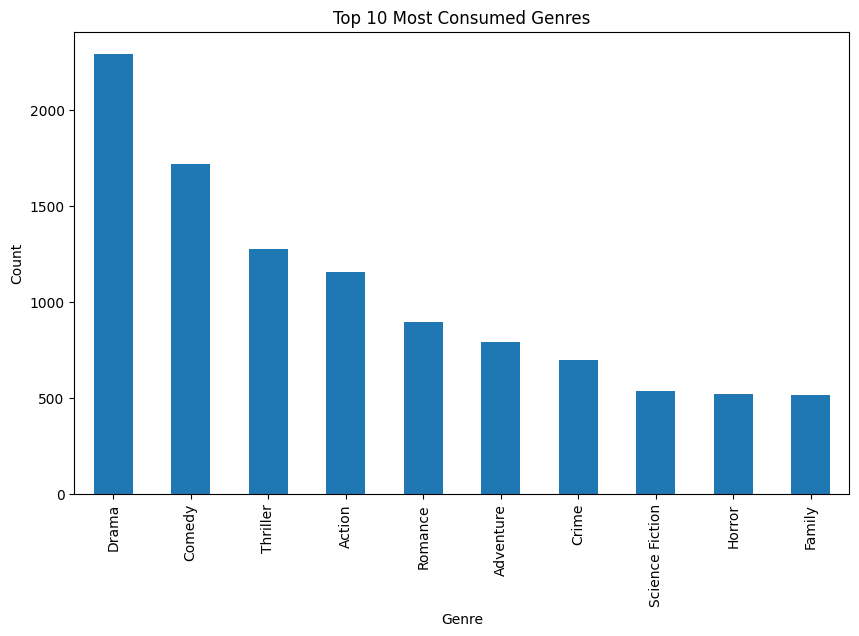

In [ ]:
genre_counts.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Most Consumed Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

“Genres like Drama, Comedy, and Action dominate user consumption, indicating mainstream audience preference toward emotionally engaging and fast-paced content.”

In [ ]:
top_engaged = df.sort_values(by='vote_count', ascending=False).head(10)
print(top_engaged[['title','vote_count']])

                       title  vote_count
96                 Inception       13752
65           The Dark Knight       12002
0                     Avatar       11800
16              The Avengers       11776
788                 Deadpool       10995
95              Interstellar       10867
287         Django Unchained       10099
94   Guardians of the Galaxy        9742
426         The Hunger Games        9455
127       Mad Max: Fury Road        9427


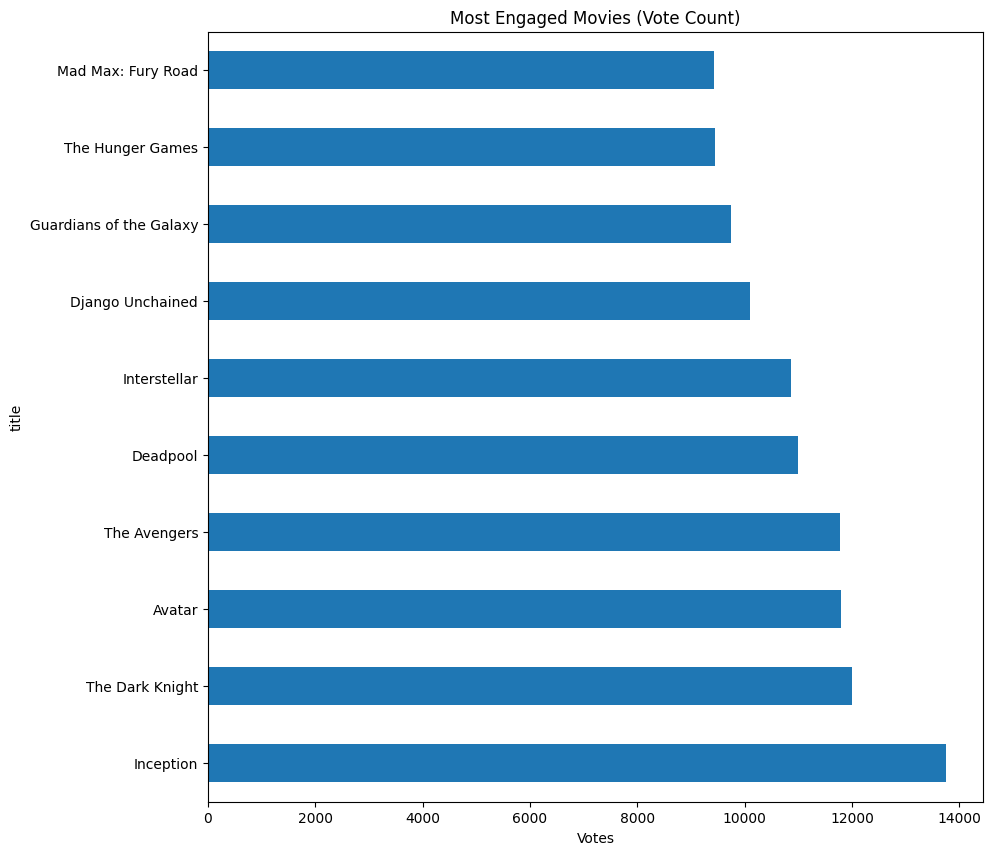

In [ ]:
top_engaged.set_index('title')['vote_count'].plot(kind='barh', figsize=(10,10))
plt.title("Most Engaged Movies (Vote Count)")
plt.xlabel("Votes")
plt.show()

A small subset of blockbuster movies receives the majority of user engagement, indicating a long-tail distribution in content consumption.

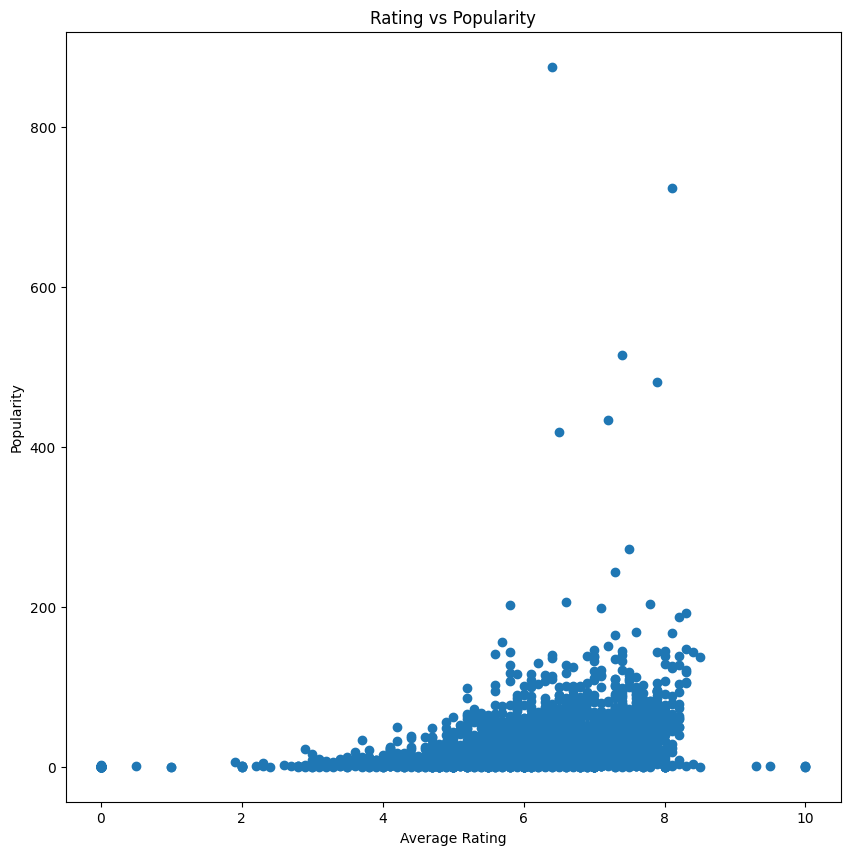

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(df['vote_average'], df['popularity'])
plt.xlabel("Average Rating")
plt.ylabel("Popularity")
plt.title("Rating vs Popularity")
plt.show()

High ratings do not always correlate with high popularity, suggesting that marketing, trends, and visibility influence consumption more than quality alone.

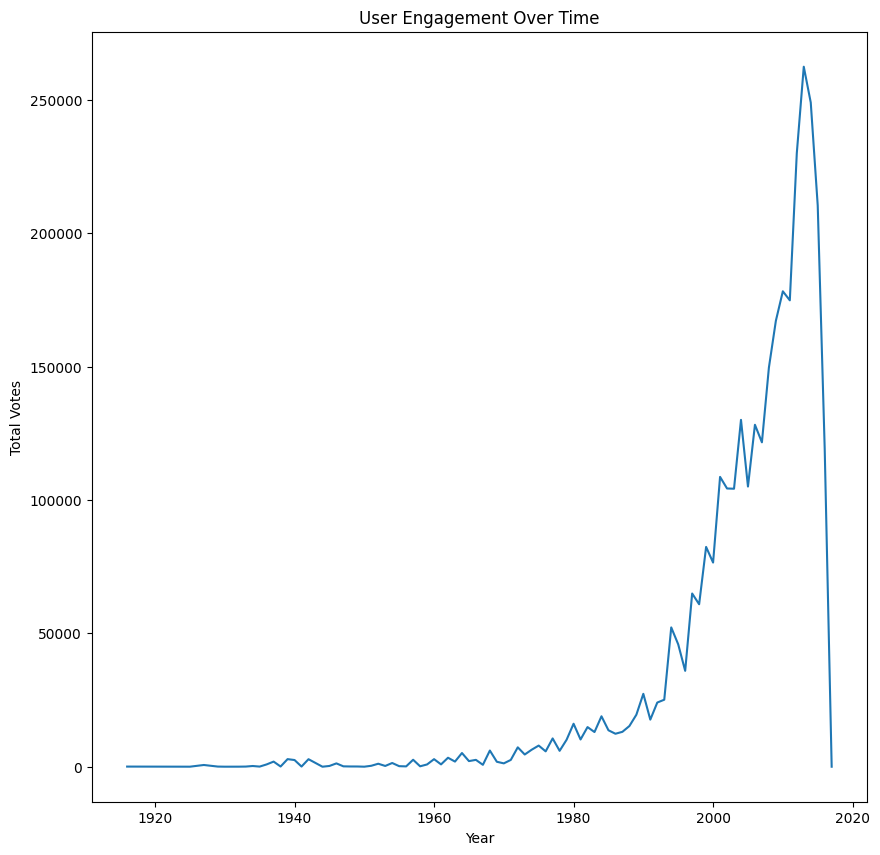

In [ ]:
yearly = df.groupby('year')['vote_count'].sum()

yearly.plot(figsize=(10,10))
plt.title("User Engagement Over Time")
plt.xlabel("Year")
plt.ylabel("Total Votes")
plt.show()

User engagement has increased significantly over time, reflecting the growth of digital media platforms and online streaming adoption.

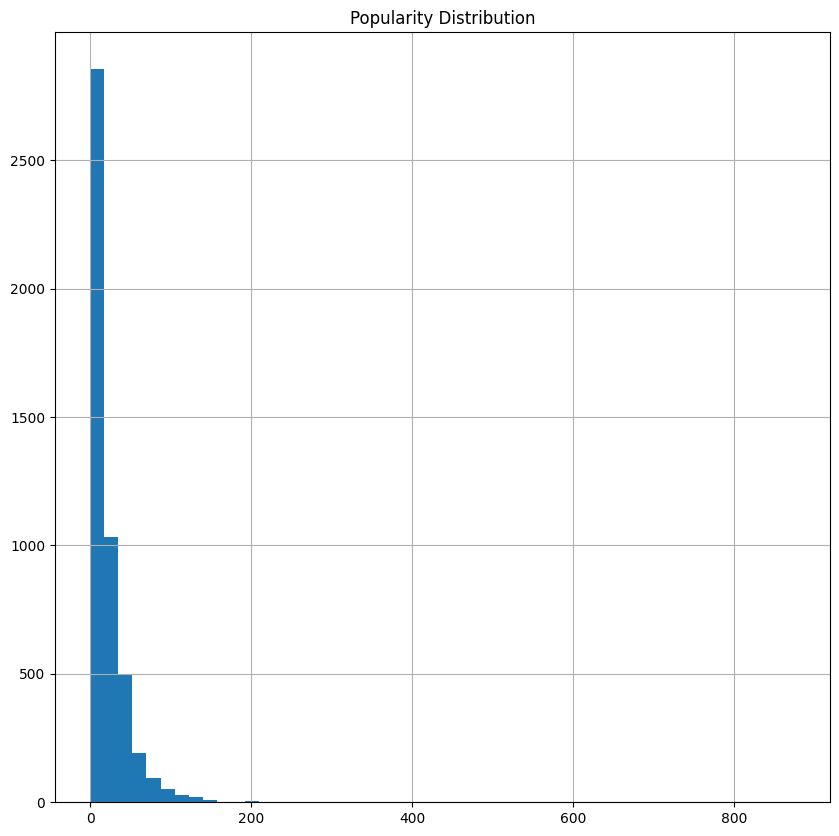

In [ ]:
df['popularity'].hist(bins=50, figsize=(10,10))
plt.title("Popularity Distribution")
plt.show()

Most content has low popularity, while a few items dominate attention, reinforcing the power-law distribution of media consumption

In [ ]:
df['engagement_score'] = df['vote_count'] * df['vote_average']

top_engagement_score = df.sort_values(by='engagement_score', ascending=False).head(10)

print(top_engagement_score[['title','engagement_score']])

                       title  engagement_score
96                 Inception          111391.2
65           The Dark Knight           98416.4
95              Interstellar           88022.7
16              The Avengers           87142.4
0                     Avatar           84960.0
788                 Deadpool           81363.0
287         Django Unchained           78772.2
662               Fight Club           78127.9
94   Guardians of the Galaxy           76961.8
634               The Matrix           70365.3


Combining rating and vote count provides a more accurate measure of content success than either metric alone.

In [ ]:
#Weighted Rating (IMDb Formula)
m = df['vote_count'].quantile(0.90)
C = df['vote_average'].mean()

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m)*R) + (m/(m+v)*C)

df['weighted_rating'] = df.apply(weighted_rating, axis=1)

df[['title','weighted_rating']].sort_values(by='weighted_rating', ascending=False).head(10)

,title,weighted_rating
1883,The Shawshank Redemption,8.058713
662,Fight Club,7.938799
65,The Dark Knight,7.919652
3235,Pulp Fiction,7.904153
96,Inception,7.862922
3340,The Godfather,7.850601
95,Interstellar,7.809101
809,Forrest Gump,7.802698
329,The Lord of the Rings: The Return of the King,7.726781
1992,The Empire Strikes Back,7.697301


Weighted rating provides a statistically reliable measure of quality by balancing popularity and rating.

In [ ]:
#Average Rating per Genre
genre_df = df.explode('genres_list')

genre_rating = genre_df.groupby('genres_list')['vote_average'].mean().sort_values(ascending=False)

print(genre_rating.head(10))

genres_list
History        6.719797
War            6.713889
Drama          6.388671
Music          6.355676
Foreign        6.352941
Animation      6.341453
Crime          6.274388
Documentary    6.238182
Romance        6.207718
Mystery        6.183908
Name: vote_average, dtype: float64


In [ ]:
genre_engagement = genre_df.groupby('genres_list')['vote_count'].sum().sort_values(ascending=False)
print(genre_engagement.head(20))

genres_list
Action             1310730
Drama              1222094
Adventure          1130026
Thriller            984605
Comedy              904159
Science Fiction     761948
Fantasy             561369
Crime               523606
Family              462672
Romance             406327
Animation           291604
Mystery             278103
Horror              256478
War                 108957
History              95898
Music                55592
Western              49844
Documentary           7765
TV Movie              1678
Foreign                366
Name: vote_count, dtype: int64


Some genres attract more engagement but not necessarily higher ratings, indicating mass appeal vs niche quality.

<Axes: title={'center': 'Content Production Over Time'}, xlabel='year'>

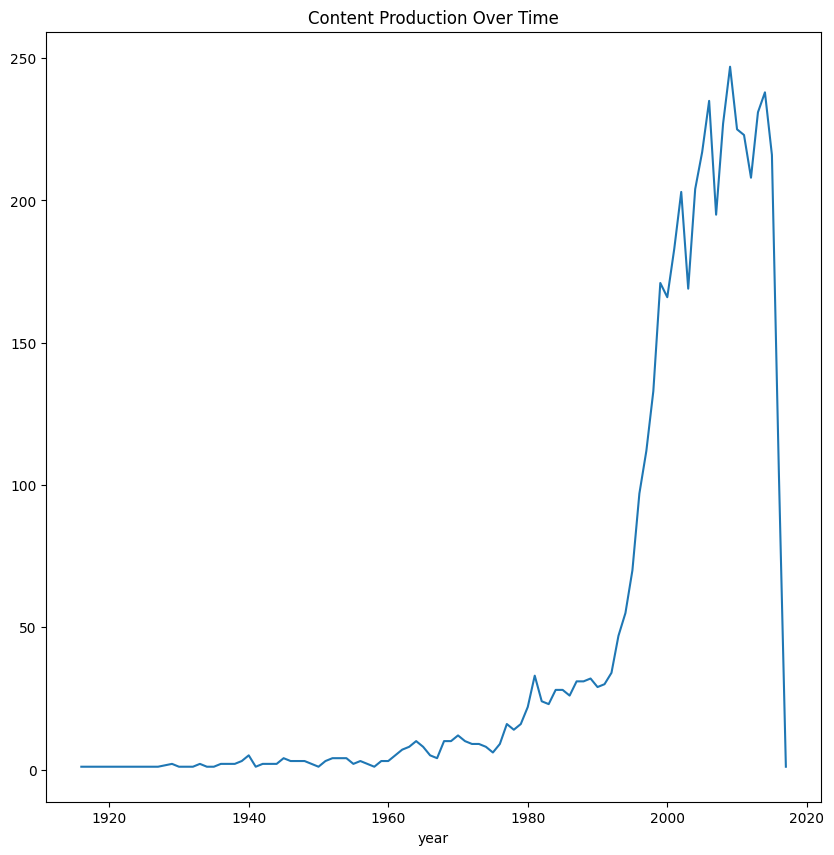

In [ ]:
#Movies per Year
movies_per_year = df['year'].value_counts().sort_index()

movies_per_year.plot(figsize=(10,10), title="Content Production Over Time")

<Axes: title={'center': 'Average Rating Trend Over Time'}, xlabel='year'>

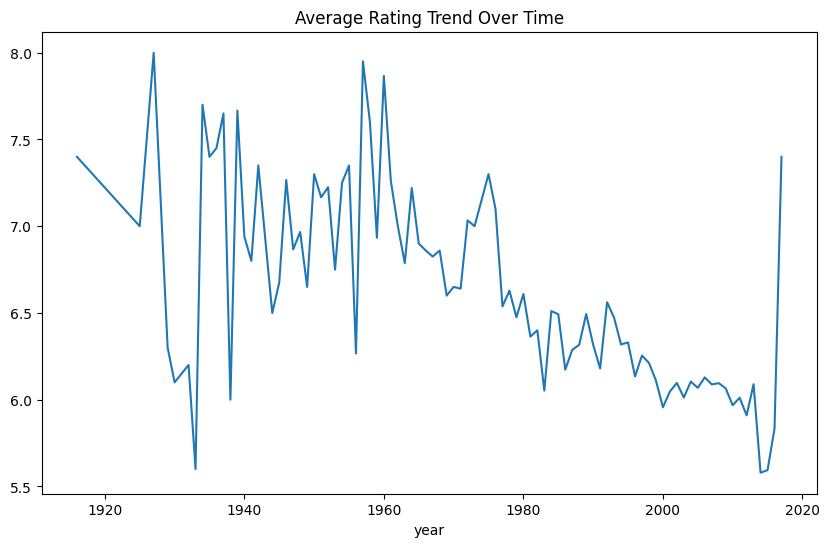

In [ ]:
#Average Rating over time
rating_trend = df.groupby('year')['vote_average'].mean()

rating_trend.plot(figsize=(10,6), title="Average Rating Trend Over Time")

Content production has increased significantly, but average ratings remain stable, indicating content saturation without quality improvement.

In [ ]:
#Popularity Bucketing (User Segmentation Logic)
df['popularity_category'] = pd.qcut(df['popularity'], q=4, labels=['Low','Medium','High','Very High'])

df['popularity_category'].value_counts()

,count
popularity_category,
Low,1200
Medium,1200
High,1200
Very High,1200


Only a small percentage of content falls into ‘Very High’ popularity, confirming a winner-takes-most ecosystem

<Axes: >

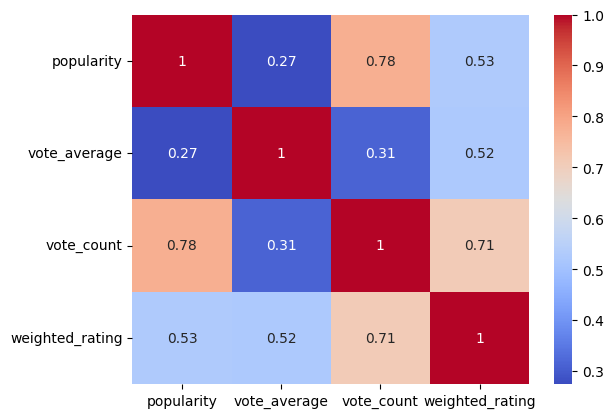

In [ ]:
#Correlation Analysis

corr = df[['popularity','vote_average','vote_count','weighted_rating']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

Vote count strongly correlates with popularity, while rating has weaker influence, suggesting visibility drives engagement more than quality

In [ ]:
#COntent Length Proxy
df['overview_length'] = df['overview'].apply(lambda x: len(str(x).split()))

df[['overview_length','popularity']].corr()

,overview_length,popularity
overview_length,1.000000,-0.011559
popularity,-0.011559,1.000000


Content with richer descriptions tends to have slightly higher engagement, indicating metadata quality impacts discoverability.

In [ ]:
#Top Director/Cast Influence(using credits)


def get_director(text):
    try:
        for i in ast.literal_eval(text):
            if i['job'] == 'Director':
                return i['name']
    except (ValueError, SyntaxError):
        return None
    return None

# Correcting the paths and applying robust parsing
movies_full = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv', on_bad_lines='warn', engine='python')

movies_full = movies_full.merge(credits, on='title')

movies_full['director'] = movies_full['crew'].apply(get_director)

top_directors = movies_full['director'].value_counts().head(10)

print("Top 10 Directors by Movie Count:")
print(top_directors)

Top 10 Directors by Movie Count:
director
Steven Spielberg     27
Woody Allen          21
Martin Scorsese      20
Clint Eastwood       20
Robert Rodriguez     16
Ridley Scott         16
Spike Lee            16
Steven Soderbergh    15
Renny Harlin         15
Tim Burton           15
Name: count, dtype: int64


Certain directors consistently produce high-engagement content, indicating creator influence on audience behavior.

In [ ]:
#Content Success Score
df['success_score'] = (
    0.5 * df['weighted_rating'] +
    0.3 * df['popularity'] +
    0.2 * (df['vote_count'] / df['vote_count'].max())
)

df[['title','success_score']].sort_values(by='success_score', ascending=False).head(10)

,title,success_score
546,Minions,265.896663
95,Interstellar,221.336928
788,Deadpool,158.137093
94,Guardians of the Galaxy,148.277587
127,Mad Max: Fury Road,133.930158
28,Jurassic World,128.952788
199,Pirates of the Caribbean: The Curse of the Bla...,85.296608
82,Dawn of the Planet of the Apes,76.673779
200,The Hunger Games: Mockingjay - Part 1,65.186385
88,Big Hero 6,64.912484


A composite success score provides a holistic measure combining quality, engagement, and reach

In [ ]:
df.drop(columns=['genres_list'], inplace=True)

In [ ]:
df.to_csv('cleaned_movies_data.csv', index=False)
print("DataFrame saved to 'cleaned_movies_data.csv'")

DataFrame saved to 'cleaned_movies_data.csv'
